In [1]:
#setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance


In [2]:
# Task 0
def make_3d_moons(n_samples=3000, noise=0.2, random_state=0):
    X2, y = make_moons(
        n_samples=n_samples,
        noise=noise,
        random_state=random_state
    )
    x, y2 = X2[:, 0], X2[:, 1]
    # Lift into 3D: smooth nonlinear embedding
    z = 0.5 * np.sin(2 * x) + 0.1 * np.random.randn(n_samples)
    X3 = np.column_stack([x, y2, z])
    return X3, y

In [3]:
# Task 1
def make_torus(n_samples=2000, R=2.0, r=0.5, noise=0.05, random_state=0):
    rng = np.random.default_rng(random_state)
    u = rng.uniform(0, 2 * np.pi, n_samples)
    v = rng.uniform(0, 2 * np.pi, n_samples)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    X = np.column_stack([x, y, z])
    X += noise * rng.standard_normal(X.shape)
    return X

In [4]:
# Task 2

X_moons, y_moons = make_3d_moons(
    n_samples=5000,
    noise=0.15,
    random_state=1
)


X_moons[:, 0] *= 1.5
X_moons[:, 1] *= 1.5

# Torus
X_torus = make_torus(
    n_samples=3000,
    R=3.8,
    r=0.6,
    noise=0.05,
    random_state=2
)


y_torus = np.full(X_torus.shape[0], 2)


X = np.vstack([X_moons, X_torus])
y = np.concatenate([y_moons, y_torus])

print("Task 2 done.")
print("X shape:", X.shape)   
print("y shape:", y.shape)   
print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))


Task 2 done.
X shape: (8000, 3)
y shape: (8000,)
Class counts: {np.int64(0): np.int64(2500), np.int64(1): np.int64(2500), np.int64(2): np.int64(3000)}


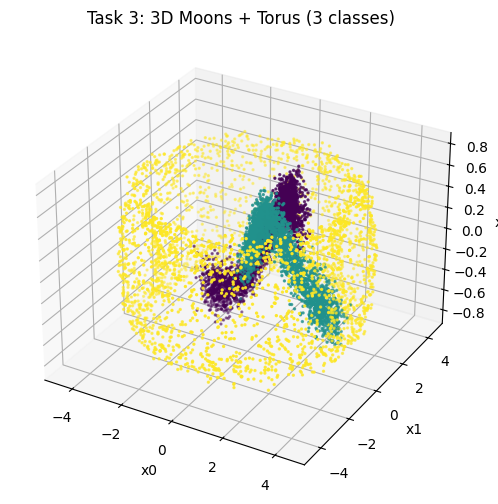

In [6]:
# Task 3
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, s=2)
ax.set_title("Task 3: 3D Moons + Torus (3 classes)")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("x2")
plt.show()

In [7]:
# Task 4

n_samples = X.shape[0]

X_noise = np.random.uniform(-4, 4, size=(n_samples, 7))
X_full = np.hstack([X, X_noise])

feature_names = [f"x{i}" for i in range(X_full.shape[1])]  # x0..x9
yX = pd.DataFrame(X_full, columns=feature_names)
yX.insert(0, "y", y)

print("yX shape:", yX.shape) 
print(yX.head())


Task 4 done.
yX shape: (8000, 11)
   y        x0        x1        x2        x3        x4        x5        x6  \
0  1  0.200369  0.179117 -0.018326 -2.418646  3.450308 -3.730155  2.344194   
1  1  2.769694  0.436675 -0.295348  1.163428 -2.132956 -3.234530  3.839303   
2  1  1.745790 -1.144202  0.242349 -1.578901 -2.805140 -0.289489 -1.734841   
3  1  0.929572 -0.560880  0.439272  2.232205  1.520726  0.227151 -0.202922   
4  1  0.009927  0.127628  0.064892  2.186956  1.129036 -0.930254 -0.379737   

         x7        x8        x9  
0  0.837920  2.578093  2.198119  
1 -2.226279 -2.315525 -3.888762  
2 -0.052180  2.921046  3.944471  
3  1.069698  1.782784  0.684991  
4  0.742907 -2.169342 -0.255106  


In [9]:
# Task 5
X_all = yX.drop(columns=["y"]).values
y_all = yX["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.25,
    random_state=0,
    stratify=y_all
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test class counts:", dict(zip(*np.unique(y_test, return_counts=True))))


Train shape: (6000, 10) Test shape: (2000, 10)
Train class counts: {np.int64(0): np.int64(1875), np.int64(1): np.int64(1875), np.int64(2): np.int64(2250)}
Test class counts: {np.int64(0): np.int64(625), np.int64(1): np.int64(625), np.int64(2): np.int64(750)}


In [11]:
# Task 6
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

param_grid = [
    # RBF 
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": [0.01, 0.1, 1, 10]
    },
    # Polynomial 
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__coef0": [0, 1, 2]
       
    }
]

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_train, y_train)

print("Best CV score:", gs.best_score_)
print("Best params:", gs.best_params_)



Best CV score: 0.9783333333333333
Best params: {'svc__C': 10, 'svc__coef0': 1, 'svc__degree': 2, 'svc__kernel': 'poly'}


In [12]:
# Task 7
cv = pd.DataFrame(gs.cv_results_)
summary_cols = ["params", "mean_test_score", "rank_test_score"]
cv_summary = cv[summary_cols].sort_values("mean_test_score", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 200)
print(cv_summary.head(10))


Task 7 done. Top 10 CV configs:
                                                                      params  \
0  {'svc__C': 100, 'svc__coef0': 2, 'svc__degree': 2, 'svc__kernel': 'poly'}   
1  {'svc__C': 100, 'svc__coef0': 1, 'svc__degree': 2, 'svc__kernel': 'poly'}   
2   {'svc__C': 10, 'svc__coef0': 1, 'svc__degree': 2, 'svc__kernel': 'poly'}   
3   {'svc__C': 10, 'svc__coef0': 2, 'svc__degree': 2, 'svc__kernel': 'poly'}   
4    {'svc__C': 1, 'svc__coef0': 2, 'svc__degree': 3, 'svc__kernel': 'poly'}   
5    {'svc__C': 1, 'svc__coef0': 1, 'svc__degree': 3, 'svc__kernel': 'poly'}   
6  {'svc__C': 0.1, 'svc__coef0': 2, 'svc__degree': 4, 'svc__kernel': 'poly'}   
7                  {'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}   
8    {'svc__C': 1, 'svc__coef0': 2, 'svc__degree': 4, 'svc__kernel': 'poly'}   
9   {'svc__C': 10, 'svc__coef0': 2, 'svc__degree': 3, 'svc__kernel': 'poly'}   

   mean_test_score  rank_test_score  
0         0.978333                1  
1         

In [14]:
# Task 8
best_model = gs.best_estimator_
best_params = gs.best_params_
best_cv_acc = gs.best_score_

print("Best params:", best_params)
print("Mean CV accuracy:", best_cv_acc)

yhat_train = best_model.predict(X_train)
yhat_test = best_model.predict(X_test)
print("Train accuracy:", accuracy_score(y_train, yhat_train))
print("Test accuracy:", accuracy_score(y_test, yhat_test))


Best params: {'svc__C': 10, 'svc__coef0': 1, 'svc__degree': 2, 'svc__kernel': 'poly'}
Mean CV accuracy: 0.9783333333333333
Train accuracy: 0.9838333333333333
Test accuracy: 0.9815


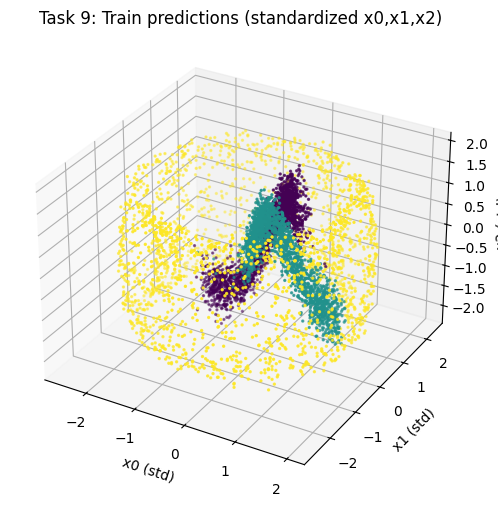

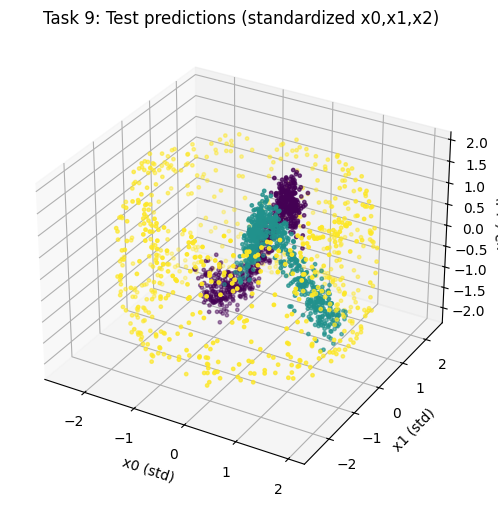

In [15]:
# Task 9

scaler = best_model.named_steps["scaler"]
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

yhat_train = best_model.predict(X_train)
yhat_test = best_model.predict(X_test)

# Train plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_train_std[:, 0], X_train_std[:, 1], X_train_std[:, 2], c=yhat_train, s=2)
ax.set_title("Task 9: Train predictions (standardized x0,x1,x2)")
ax.set_xlabel("x0 (std)")
ax.set_ylabel("x1 (std)")
ax.set_zlabel("x2 (std)")
plt.show()

# Test plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_test_std[:, 0], X_test_std[:, 1], X_test_std[:, 2], c=yhat_test, s=6)
ax.set_title("Task 9: Test predictions (standardized x0,x1,x2)")
ax.set_xlabel("x0 (std)")
ax.set_ylabel("x1 (std)")
ax.set_zlabel("x2 (std)")
plt.show()

  feature  importance_mean  importance_std
0      x1          0.45625        0.013220
1      x0          0.37600        0.008050
2      x2          0.15610        0.006774
3      x7          0.00085        0.000867
4      x9          0.00030        0.000600
5      x3         -0.00005        0.000850
6      x4         -0.00050        0.000894
7      x8         -0.00085        0.000709
8      x6         -0.00145        0.000723
9      x5         -0.00175        0.000873


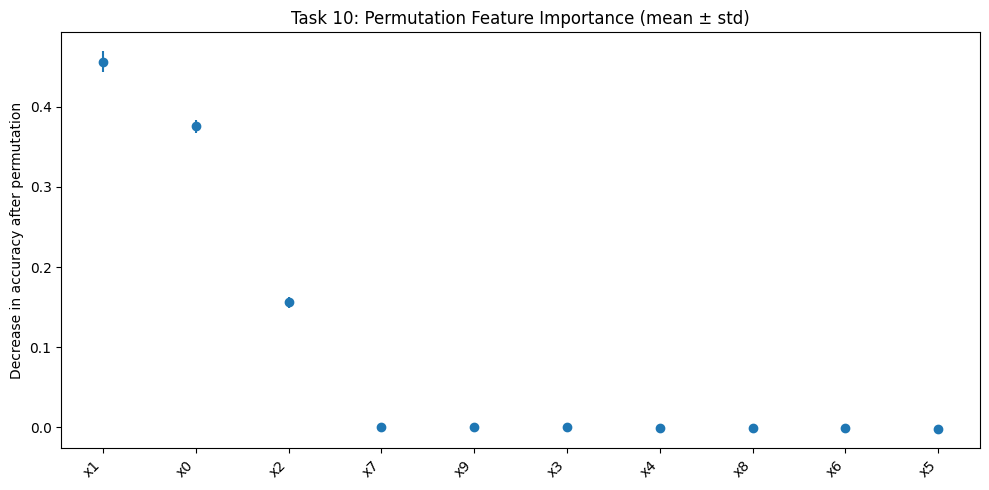

In [16]:
# Task 10
perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring="accuracy",
    n_jobs=-1
)

importances_mean = perm.importances_mean
importances_std = perm.importances_std

fi = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": importances_mean,
    "importance_std": importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print(fi.head(10))

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=np.arange(len(feature_names)),
    y=fi["importance_mean"].values,
    yerr=fi["importance_std"].values,
    fmt="o"
)
plt.xticks(np.arange(len(feature_names)), fi["feature"].values, rotation=45, ha="right")
plt.title("Task 10: Permutation Feature Importance")
plt.ylabel("Decrease in accuracy after permutation")
plt.tight_layout()
plt.show()

In [18]:
# Task 11
top3 = fi.head(3)
rest = fi.iloc[3:]

print("Top-3 features by importance:\n", top3[["feature", "importance_mean"]])

print("\nMean importance of top-3:", top3["importance_mean"].mean())
print("Mean importance of remaining 7:", rest["importance_mean"].mean())


Top-3 features by importance:
   feature  importance_mean
0      x1          0.45625
1      x0          0.37600
2      x2          0.15610

Mean importance of top-3: 0.3294500000000001
Mean importance of remaining 7: -0.0004928571428571155
